In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["font.size"] = 12

In [2]:
deliveries = pd.read_csv(
    'https://raw.githubusercontent.com/iiitl/EDA-IPL/main/data/deliveries.csv'
)
print("Deliveries shape:", deliveries.shape)
matches = pd.read_csv(
    'https://raw.githubusercontent.com/iiitl/EDA-IPL/main/data/matches.csv'
)
print("Matches shape:", matches.shape)
print("Deliveries columns:")
print(deliveries.columns.tolist())

print("Matches columns:")
print(matches.columns.tolist())

print("First 5 rows of deliveries:")
deliveries.head()

Deliveries shape: (260920, 17)
Matches shape: (1095, 20)
Deliveries columns:
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']
Matches columns:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']
First 5 rows of deliveries:


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [3]:
match_seasons = matches[['id', 'season']].copy()
match_seasons = match_seasons.rename(columns={'id': 'match_id'})
df = deliveries.merge(match_seasons, on='match_id', how='left')
print("After merge shape:", df.shape)
print("Season column sample:")
print(df[['match_id', 'season']].head(10))
print(sorted(df['season'].unique()))


After merge shape: (260920, 18)
Season column sample:
   match_id   season
0    335982  2007/08
1    335982  2007/08
2    335982  2007/08
3    335982  2007/08
4    335982  2007/08
5    335982  2007/08
6    335982  2007/08
7    335982  2007/08
8    335982  2007/08
9    335982  2007/08
['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']


In [4]:
print("Unique extras_type values:")
print(df['extras_type'].unique())
df['extras_type'] = df['extras_type'].fillna('none')
legal = df[~df['extras_type'].isin(['wides', 'noballs'])]
print(f"Total deliveries: {len(df)}")
print(f"Legal deliveries only: {len(legal)}")
print(f"Wides + No-balls removed: {len(df) - len(legal)}")

Unique extras_type values:
['legbyes' nan 'wides' 'byes' 'noballs' 'penalty']
Total deliveries: 260920
Legal deliveries only: 251471
Wides + No-balls removed: 9449


In [5]:
season_stats = legal.groupby('season').agg(total_runs=('total_runs', 'sum'),total_legal_deliveries=('total_runs', 'count')).reset_index()
season_stats['legal_overs'] = season_stats['total_legal_deliveries'] / 6
season_stats['avg_run_rate'] =(season_stats['total_runs'] / season_stats['legal_overs']).round(3)
print("Season stats so far:")
print(season_stats[['season', 'total_runs', 'legal_overs', 'avg_run_rate']])


Season stats so far:
     season  total_runs  legal_overs  avg_run_rate
0   2007/08       17140  2158.333333         7.941
1      2009       15661  2182.500000         7.176
2   2009/10       18100  2323.000000         7.792
3      2011       20334  2737.500000         7.428
4      2012       21685  2868.000000         7.561
5      2013       21871  2939.500000         7.440
6      2014       18319  2307.666667         7.938
7      2015       17701  2191.666667         8.077
8      2016       18208  2269.666667         8.022
9      2017       18199  2233.500000         8.148
10     2018       19337  2301.333333         8.403
11     2019       18828  2309.500000         8.152
12  2020/21       18776  2343.166667         8.013
13     2021       17937  2314.666667         7.749
14     2022       23372  2856.833333         8.181
15     2023       24676  2857.500000         8.636
16     2024       24924  2717.500000         9.172


In [6]:
dot_balls = legal[legal['total_runs'] == 0].groupby('season').size()
dot_balls = dot_balls.reset_index()
dot_balls.columns = ['season', 'dot_balls']
season_stats = season_stats.merge(dot_balls, on='season', how='left')
season_stats['dot_ball_pct'] = (season_stats['dot_balls'] / season_stats['total_legal_deliveries'] * 100).round(3)
print("Season stats with dot ball %:")
print(season_stats[['season', 'avg_run_rate', 'dot_ball_pct']])


Season stats with dot ball %:
     season  avg_run_rate  dot_ball_pct
0   2007/08         7.941        37.961
1      2009         7.176        39.091
2   2009/10         7.792        35.844
3      2011         7.428        38.247
4      2012         7.561        36.268
5      2013         7.440        38.323
6      2014         7.938        36.234
7      2015         8.077        36.312
8      2016         8.022        34.139
9      2017         8.148        33.960
10     2018         8.403        34.422
11     2019         8.152        35.621
12  2020/21         8.013        34.725
13     2021         7.749        36.161
14     2022         8.181        37.075
15     2023         8.636        33.928
16     2024         9.172        32.922


In [7]:
season_stats = season_stats.sort_values('season').reset_index(drop=True)
season_stats['rr_yoy_change'] = season_stats['avg_run_rate'].pct_change() * 100
season_stats['db_yoy_change'] = season_stats['dot_ball_pct'].pct_change() * 100
print("Year-over-year changes:")
print(season_stats[['season', 'avg_run_rate', 'rr_yoy_change','dot_ball_pct', 'db_yoy_change']].to_string())

Year-over-year changes:
     season  avg_run_rate  rr_yoy_change  dot_ball_pct  db_yoy_change
0   2007/08         7.941            NaN        37.961            NaN
1      2009         7.176      -9.633547        39.091       2.976739
2   2009/10         7.792       8.584169        35.844      -8.306260
3      2011         7.428      -4.671458        38.247       6.704051
4      2012         7.561       1.790522        36.268      -5.174262
5      2013         7.440      -1.600317        38.323       5.666152
6      2014         7.938       6.693548        36.234      -5.451035
7      2015         8.077       1.751071        36.312       0.215267
8      2016         8.022      -0.680946        34.139      -5.984248
9      2017         8.148       1.570681        33.960      -0.524327
10     2018         8.403       3.129602        34.422       1.360424
11     2019         8.152      -2.987028        35.621       3.483237
12  2020/21         8.013      -1.705103        34.725      -2.515

In [8]:
correlation = season_stats['avg_run_rate'].corr(season_stats['dot_ball_pct'])
print(f"Pearson Correlation (Run Rate vs Dot Ball %):")
print(f"  r = {correlation:.4f}")
print("Full correlation matrix:")
print(season_stats[['avg_run_rate', 'dot_ball_pct']].corr())

Pearson Correlation (Run Rate vs Dot Ball %):
  r = -0.8186

Full correlation matrix:
              avg_run_rate  dot_ball_pct
avg_run_rate      1.000000     -0.818647
dot_ball_pct     -0.818647      1.000000


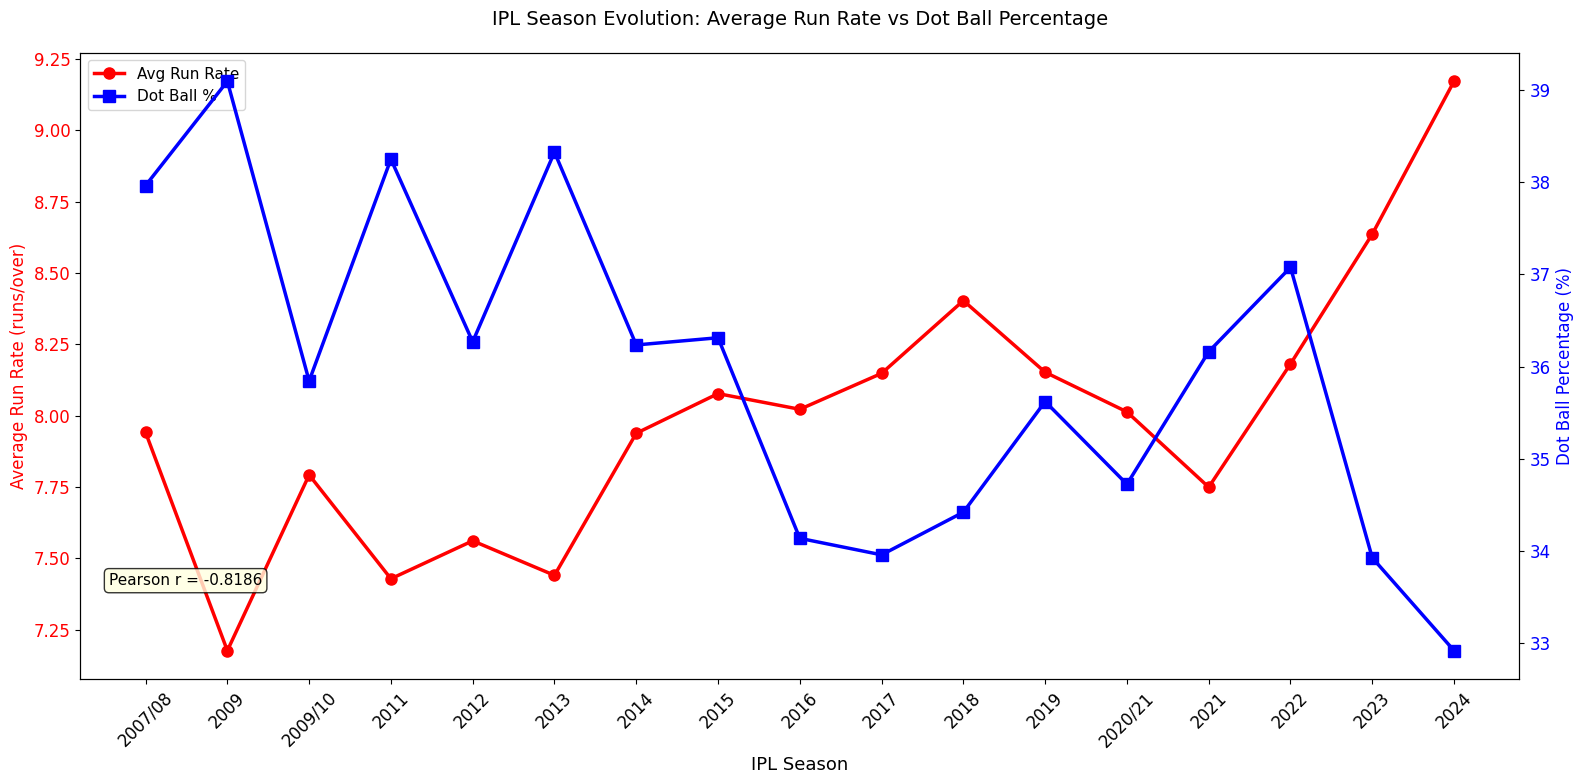

In [11]:
fig, ax1 = plt.subplots(figsize=(16, 8))
color_rr='red'
color_db='blue'
ax1.plot(season_stats['season'].astype(str),season_stats['avg_run_rate'], color=color_rr,marker='o',linewidth=2.5,markersize=8,label='Avg Run Rate')
ax1.set_xlabel('IPL Season', fontsize=13)
ax1.set_ylabel('Average Run Rate (runs/over)', color=color_rr, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_rr)
ax1.tick_params(axis='x', rotation=45)
ax2 = ax1.twinx()
ax2.plot(season_stats['season'].astype(str),season_stats['dot_ball_pct'], color=color_db,marker='s',linewidth=2.5,markersize=8,  label='Dot Ball %')
ax2.set_ylabel('Dot Ball Percentage (%)', color=color_db, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_db)
plt.title(
    'IPL Season Evolution: Average Run Rate vs Dot Ball Percentage',
    fontsize=14, pad=20
)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)
ax1.text(0.02, 0.15,f'Pearson r = {correlation:.4f}',transform=ax1.transAxes,fontsize=11,bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.savefig('season_scoring_rates.png', bbox_inches='tight')
plt.show()


In [12]:
print("*=" * 30)
print("FINAL SUMMARY TABLE")
print("*=" * 30)
print(season_stats[['season', 'avg_run_rate', 'dot_ball_pct',
                     'rr_yoy_change', 'db_yoy_change']].to_string(index=False))

print(f"\nOverall Run Rate change ({season_stats['season'].min()} → "
      f"{season_stats['season'].max()}):")
first_rr = season_stats['avg_run_rate'].iloc[0]
last_rr  = season_stats['avg_run_rate'].iloc[-1]
print(f"  {first_rr} → {last_rr} "
      f"({((last_rr-first_rr)/first_rr*100):+.1f}%)")

print(f"\nOverall Dot Ball % change:")
first_db = season_stats['dot_ball_pct'].iloc[0]
last_db  = season_stats['dot_ball_pct'].iloc[-1]
print(f"  {first_db}% → {last_db}% "
      f"({((last_db-first_db)/first_db*100):+.1f}%)")

print(f"\nPearson r = {correlation:.4f}")

*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=
FINAL SUMMARY TABLE
*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=
 season  avg_run_rate  dot_ball_pct  rr_yoy_change  db_yoy_change
2007/08         7.941        37.961            NaN            NaN
   2009         7.176        39.091      -9.633547       2.976739
2009/10         7.792        35.844       8.584169      -8.306260
   2011         7.428        38.247      -4.671458       6.704051
   2012         7.561        36.268       1.790522      -5.174262
   2013         7.440        38.323      -1.600317       5.666152
   2014         7.938        36.234       6.693548      -5.451035
   2015         8.077        36.312       1.751071       0.215267
   2016         8.022        34.139      -0.680946      -5.984248
   2017         8.148        33.960       1.570681      -0.524327
   2018         8.403        34.422       3.129602       1.360424
   2019         8.152        35.621      -2.987028       3.483237
